In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re

import tqdm

In [2]:
def read_hits_tab(file, library):
    """
    Arguments
    ---
    - file: File from where to read the input
    - library: Provides a name to the library
    """
    hits = pd.read_csv(
        file, 
        sep="\s+", comment='#', header=None
    )
    hits.columns=[
        'query_id', 'ref_id', 'identity', '_', '_', '_', 'qstart', 'qend', 'rstart', 'rend', 
        '_', '_', 'score', 'qstrand', 'rstrand', 'qrlength', 'BTOP', 'difaln', '_', '_',
        '_', 'unaligned', '_', '_', '_'
    ]
    hits = hits[['query_id', 'ref_id', 'identity','qstart', 'qend', 'rstart', 'rend', 'score', 'qstrand', 'rstrand', 'qrlength', 'difaln']]
    hits['library'] = library
    return hits

In [3]:
hits = read_hits_tab('../results/marco-mapping-2025-02-25/PV64_21351_GCCAAT.hits.tab', 'PV064')

In [4]:
genome_index = pd.read_json("../data/sanchis21.genome-index.json")
genome_index

,id,species_name,taxid
0,AE016822.1,Leifsonia xyli,1575
1,AE016853.1,Pseudomonas syringae,317
2,AE016855.1,Pseudomonas syringae,317
3,AE016854.1,Pseudomonas syringae,317
4,AL646052.1,Ralstonia solanacearum,305
...,...,...,...
40058,NZ_CZWJ01000005.1,Bradyrhizobium sp.,376
40059,NZ_CZWJ01000004.1,Bradyrhizobium sp.,376
40060,NZ_CZWJ01000002.1,Bradyrhizobium sp.,376
40061,NZ_CZWJ01000001.1,Bradyrhizobium sp.,376


In [5]:
hits

,query_id,ref_id,identity,qstart,qend,rstart,rend,score,qstrand,rstrand,qrlength,difaln,library
0,J00148:56:HM5WHBBXX:1:1205:26382:14432,AKVP01000087.1,100.000,1,151,1037,887,151,plus,minus,151,1,PV064
1,J00148:56:HM5WHBBXX:1:1205:26382:14432,AKVP01000087.1,100.000,1,151,878,1028,151,plus,plus,151,1,PV064
2,J00148:56:HM5WHBBXX:1:1205:7963:14871,AKVP01000087.1,100.000,1,151,837,987,151,plus,plus,151,2,PV064
3,J00148:56:HM5WHBBXX:1:1205:7963:14871,LMNW01000030.1,100.000,1,151,164,14,151,plus,minus,151,2,PV064
4,J00148:56:HM5WHBBXX:1:1205:17371:15768,LMQW01000042.1,100.000,1,151,488,638,151,plus,plus,151,1,PV064
...,...,...,...,...,...,...,...,...,...,...,...,...,...
36512,J00148:56:HM5WHBBXX:2:2228:24068:44957,LMQW01000042.1,96.129,1,151,3708,3554,125,plus,minus,151,1,PV064
36513,J00148:56:HM5WHBBXX:2:2228:24068:44957,LMQW01000042.1,96.129,1,151,3554,3708,125,plus,plus,151,1,PV064
36514,J00148:56:HM5WHBBXX:2:2228:22851:45273,NZ_JBBLYY010000053.1,100.000,42,151,1805,1696,110,plus,minus,151,1,PV064
36515,J00148:56:HM5WHBBXX:2:2228:3112:46170,AKVP01000087.1,100.000,1,146,958,813,146,plus,minus,151,1,PV064


In [6]:
hits_taxid = pd.merge(
    hits, genome_index, 
    right_on='id', left_on='ref_id'
)
hits_taxid = hits_taxid.query('identity == 100')
hits_taxid['aln_len'] = hits_taxid['qend'] - hits_taxid['qstart']
hits_taxid = hits_taxid.query('aln_len > 125')
hits_taxid

,query_id,ref_id,identity,qstart,qend,rstart,rend,score,qstrand,rstrand,qrlength,difaln,library,id,species_name,taxid,aln_len
0,J00148:56:HM5WHBBXX:1:1205:26382:14432,AKVP01000087.1,100.0,1,151,1037,887,151,plus,minus,151,1,PV064,AKVP01000087.1,Microbacterium barkeri,33917,150
1,J00148:56:HM5WHBBXX:1:1205:26382:14432,AKVP01000087.1,100.0,1,151,878,1028,151,plus,plus,151,1,PV064,AKVP01000087.1,Microbacterium barkeri,33917,150
2,J00148:56:HM5WHBBXX:1:1205:7963:14871,AKVP01000087.1,100.0,1,151,837,987,151,plus,plus,151,2,PV064,AKVP01000087.1,Microbacterium barkeri,33917,150
3,J00148:56:HM5WHBBXX:1:1205:7963:14871,LMNW01000030.1,100.0,1,151,164,14,151,plus,minus,151,2,PV064,LMNW01000030.1,Duganella sp.,1904440,150
4,J00148:56:HM5WHBBXX:1:1205:17371:15768,LMQW01000042.1,100.0,1,151,488,638,151,plus,plus,151,1,PV064,LMQW01000042.1,Aureimonas sp.,1872658,150
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36505,J00148:56:HM5WHBBXX:2:2228:30817:43708,AKVP01000087.1,100.0,1,128,1191,1318,128,plus,plus,151,1,PV064,AKVP01000087.1,Microbacterium barkeri,33917,127
36506,J00148:56:HM5WHBBXX:2:2228:8988:44711,AKVP01000087.1,100.0,5,151,1340,1194,147,plus,minus,151,1,PV064,AKVP01000087.1,Microbacterium barkeri,33917,146
36507,J00148:56:HM5WHBBXX:2:2228:8988:44711,AKVP01000087.1,100.0,1,148,1193,1340,148,plus,plus,151,1,PV064,AKVP01000087.1,Microbacterium barkeri,33917,147
36511,J00148:56:HM5WHBBXX:2:2228:3112:46170,AKVP01000087.1,100.0,1,146,958,813,146,plus,minus,151,1,PV064,AKVP01000087.1,Microbacterium barkeri,33917,145


In [7]:
hits_taxid_dd = hits_taxid.drop_duplicates(subset=['query_id', 'ref_id'], keep='first')
hits_taxid_dd

,query_id,ref_id,identity,qstart,qend,rstart,rend,score,qstrand,rstrand,qrlength,difaln,library,id,species_name,taxid,aln_len
0,J00148:56:HM5WHBBXX:1:1205:26382:14432,AKVP01000087.1,100.0,1,151,1037,887,151,plus,minus,151,1,PV064,AKVP01000087.1,Microbacterium barkeri,33917,150
2,J00148:56:HM5WHBBXX:1:1205:7963:14871,AKVP01000087.1,100.0,1,151,837,987,151,plus,plus,151,2,PV064,AKVP01000087.1,Microbacterium barkeri,33917,150
3,J00148:56:HM5WHBBXX:1:1205:7963:14871,LMNW01000030.1,100.0,1,151,164,14,151,plus,minus,151,2,PV064,LMNW01000030.1,Duganella sp.,1904440,150
4,J00148:56:HM5WHBBXX:1:1205:17371:15768,LMQW01000042.1,100.0,1,151,488,638,151,plus,plus,151,1,PV064,LMQW01000042.1,Aureimonas sp.,1872658,150
6,J00148:56:HM5WHBBXX:1:1205:31193:15803,LMLU01000001.1,100.0,1,140,1787,1926,140,plus,plus,151,1,PV064,LMLU01000001.1,Arthrobacter sp.,1667,139
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36502,J00148:56:HM5WHBBXX:2:2228:18233:42126,AKVP01000087.1,100.0,1,142,1196,1337,142,plus,plus,151,1,PV064,AKVP01000087.1,Microbacterium barkeri,33917,141
36504,J00148:56:HM5WHBBXX:2:2228:30817:43708,AKVP01000087.1,100.0,1,128,1318,1191,128,plus,minus,151,1,PV064,AKVP01000087.1,Microbacterium barkeri,33917,127
36506,J00148:56:HM5WHBBXX:2:2228:8988:44711,AKVP01000087.1,100.0,5,151,1340,1194,147,plus,minus,151,1,PV064,AKVP01000087.1,Microbacterium barkeri,33917,146
36511,J00148:56:HM5WHBBXX:2:2228:3112:46170,AKVP01000087.1,100.0,1,146,958,813,146,plus,minus,151,1,PV064,AKVP01000087.1,Microbacterium barkeri,33917,145


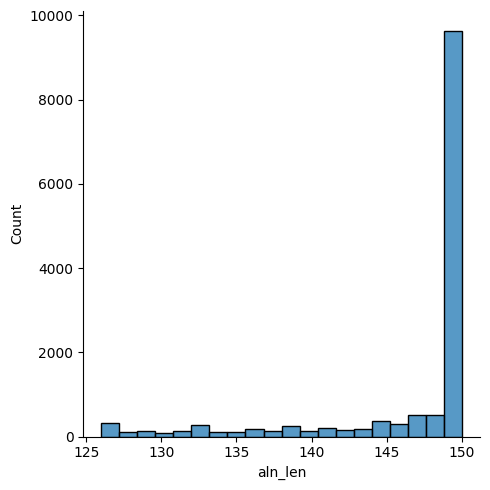

In [8]:
sns.displot(hits_taxid_dd, x='aln_len', bins=20)

In [9]:
hits_taxid_dd_by_taxid =  hits_taxid_dd.value_counts(
    subset=['taxid', 'query_id']
).reset_index()
hits_taxid_dd_by_taxid

,taxid,query_id,count
0,28214,J00148:56:HM5WHBBXX:1:1115:16518:4796,24
1,28214,J00148:56:HM5WHBBXX:1:2228:29143:23540,24
2,28214,J00148:56:HM5WHBBXX:1:1102:11749:30398,21
3,28214,J00148:56:HM5WHBBXX:2:2115:15564:26318,21
4,28214,J00148:56:HM5WHBBXX:1:1205:12855:17649,20
...,...,...,...
10030,33917,J00148:56:HM5WHBBXX:2:1205:17391:44711,1
10031,33917,J00148:56:HM5WHBBXX:2:1205:17868:39910,1
10032,33917,J00148:56:HM5WHBBXX:2:1205:19268:14203,1
10033,33917,J00148:56:HM5WHBBXX:2:1205:21014:38785,1


In [10]:
hits_taxid_dd_unambiguous_ids = hits_taxid_dd_by_taxid.value_counts(
    subset=['query_id']
).reset_index()# .query('count < 2')['query_id'].to_list()

hits_taxid_dd_unambiguous_ids

,query_id,count
0,J00148:56:HM5WHBBXX:1:2125:19228:33510,15
1,J00148:56:HM5WHBBXX:1:1110:2706:12163,14
2,J00148:56:HM5WHBBXX:1:2109:15047:19197,13
3,J00148:56:HM5WHBBXX:1:2125:31121:28903,13
4,J00148:56:HM5WHBBXX:1:2114:7456:10616,13
...,...,...
7105,J00148:56:HM5WHBBXX:1:2127:8410:3899,1
7106,J00148:56:HM5WHBBXX:1:2127:7588:37255,1
7107,J00148:56:HM5WHBBXX:1:2127:5528:46135,1
7108,J00148:56:HM5WHBBXX:1:2127:3934:27901,1


In [11]:
selected_hits = hits_taxid_dd_unambiguous_ids.query('count < 2')['query_id'].to_list()

In [12]:
species_hits = pd.merge(
    hits[hits['query_id'].isin(selected_hits)], genome_index[['id', 'species_name', 'taxid']], 
    right_on='id', left_on='ref_id'
).value_counts(subset=['species_name', 'taxid']).reset_index()

In [13]:
species_hits['log_count'] = species_hits['count'].apply(np.log10)

In [14]:
species_hits.query('count > 1')

,species_name,taxid,count,log_count
0,Microbacterium barkeri,33917,3857,3.586250
1,Aureimonas sp.,1872658,2281,3.358125
2,Sphingomonas sp.,28214,829,2.918555
3,Duganella sp.,1904440,798,2.902003
4,Arthrobacter sp.,1667,264,2.421604
...,...,...,...,...
63,Leifsonia xyli,1575,2,0.301030
64,Mesoplasma florum,2151,2,0.301030
65,Methylobacterium extorquens,408,2,0.301030
66,Pseudomonas stutzeri,316,2,0.301030


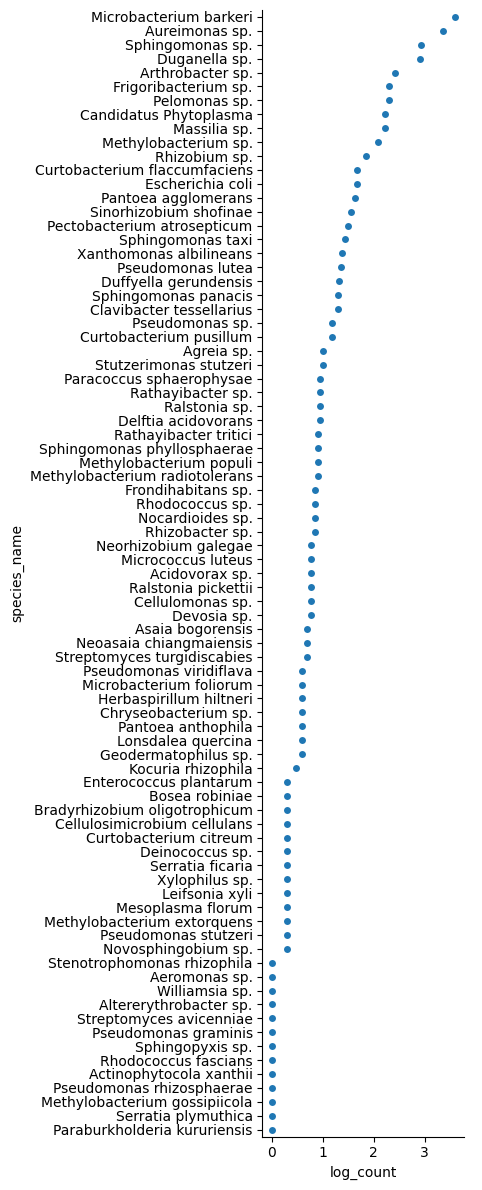

In [15]:
g = sns.catplot(y='species_name', x='log_count', data=species_hits, aspect=0.4, height=12.0)
# g[0,0].set_xscale('log')

In [22]:
marco_species_count = pd.read_csv(
    "../data/marco.pv064.species_counts.csv", sep="\t"
)
marco_species_count[:10]

,OTU,lib,taxon,site,habitat,count
0,Arthrobacter sp. Leaf234,PV064,Artemisia_herba_alba,E1,waste,94
1,Aureimonas sp. Leaf324,PV064,Artemisia_herba_alba,E1,waste,16
2,Caulobacter zeae,PV064,Artemisia_herba_alba,E1,waste,2
3,Cellulomonas sp. Leaf334,PV064,Artemisia_herba_alba,E1,waste,4
4,Cupriavidus gilardii,PV064,Artemisia_herba_alba,E1,waste,28
5,Duganella sp. Leaf126,PV064,Artemisia_herba_alba,E1,waste,1494
6,Dyadobacter endophyticus,PV064,Artemisia_herba_alba,E1,waste,774
7,Ensifer shofinae,PV064,Artemisia_herba_alba,E1,waste,576
8,Epibacterium ulvae,PV064,Artemisia_herba_alba,E1,waste,2
9,Frigoribacterium endophyticum,PV064,Artemisia_herba_alba,E1,waste,6


In [28]:
marco_species_count['species_name'] = marco_species_count['OTU'].apply(
    lambda x: x.split(' ')[0] + ' ' + x.split(' ')[1]
)
marco_species_count

,OTU,lib,taxon,site,habitat,count,species_name
0,Arthrobacter sp. Leaf234,PV064,Artemisia_herba_alba,E1,waste,94,Arthrobacter sp.
1,Aureimonas sp. Leaf324,PV064,Artemisia_herba_alba,E1,waste,16,Aureimonas sp.
2,Caulobacter zeae,PV064,Artemisia_herba_alba,E1,waste,2,Caulobacter zeae
3,Cellulomonas sp. Leaf334,PV064,Artemisia_herba_alba,E1,waste,4,Cellulomonas sp.
4,Cupriavidus gilardii,PV064,Artemisia_herba_alba,E1,waste,28,Cupriavidus gilardii
5,Duganella sp. Leaf126,PV064,Artemisia_herba_alba,E1,waste,1494,Duganella sp.
6,Dyadobacter endophyticus,PV064,Artemisia_herba_alba,E1,waste,774,Dyadobacter endophyticus
7,Ensifer shofinae,PV064,Artemisia_herba_alba,E1,waste,576,Ensifer shofinae
8,Epibacterium ulvae,PV064,Artemisia_herba_alba,E1,waste,2,Epibacterium ulvae
9,Frigoribacterium endophyticum,PV064,Artemisia_herba_alba,E1,waste,6,Frigoribacterium endophyticum


In [37]:
pd.merge(marco_species_count, species_hits, on='species_name', how='inner').sort_values(
    by='count_y', ascending=False)[['species_name', 'taxid', 'count_x', 'count_y']]

,species_name,taxid,count_x,count_y
5,Microbacterium barkeri,33917,4248,3857
1,Aureimonas sp.,1872658,16,2281
3,Duganella sp.,1904440,1494,798
0,Arthrobacter sp.,1667,94,264
8,Pseudomonas lutea,243924,6,23
10,Sphingomonas panacis,1560345,2,20
9,Rathayibacter tritici,33888,2,8
7,Nocardioides sp.,35761,4,7
2,Cellulomonas sp.,40001,4,6
6,Neoasaia chiangmaiensis,320497,2,5


In [103]:
def obtain_species_from_hits(hits, genome_index, library):

    deduplicated_hits = pd.merge(
        hits, genome_index[['id', 'species_name']], 
        right_on='id', left_on='ref_id'
    ).drop_duplicates(subset=['query_id', 'ref_id']).value_counts(
        subset=['species_name', 'query_id']
    ).reset_index().value_counts(
        subset=['query_id']
    ).reset_index().query('count < 2')['query_id'].to_list()

    species_hits = pd.merge(
        hits[hits['query_id'].isin(deduplicated_hits)], genome_index[['id', 'species_name', 'taxid']], 
        right_on='id', left_on='ref_id'
    ).value_counts(subset=['species_name', 'taxid']).reset_index()
    species_hits['library'] = library

    return species_hits

In [104]:
filename = '../results/marco-mapping-2025-02-25/PV64_21351_GCCAAT.hits.tab'
library_name = 'PV064'
hits = read_hits_tab(filename, library_name)
species = obtain_species_from_hits(hits, genome_index, library_name)
species

,species_name,taxid,count,library
0,Aureimonas sp.,1872658,6054,PV064
1,Microbacterium barkeri,33917,4943,PV064
2,Sphingomonas sp.,28214,1054,PV064
3,Duganella sp.,1904440,1044,PV064
4,Candidatus Phytoplasma,33926,680,PV064
...,...,...,...,...
105,Methylobacterium pseudosasicola,582667,1,PV064
106,Curtobacterium sp.,1869344,1,PV064
107,Rhodococcus fascians,1828,1,PV064
108,Curtobacterium luteum,33881,1,PV064


In [105]:
species.to_json(
    "../results/marco-mapping-2025-02-25/PV064_21351_GCCAAT.species.json", 
    orient='records', indent=4
)

In [106]:
pd.merge(hits, genome_index, left_on='ref_id', right_on='id').query('species_name == "Arthrobacter sp. Leaf234"')

,query_id,ref_id,identity,qstart,qend,rstart,rend,score,qstrand,rstrand,qrlength,difaln,library,id,species_name,taxid
